# Global Geo-Economic Stress Indicators

## Objective
Develop a machine learning framework to analyze and predict economic stress across countries using macroeconomic indicators.

## Datasets
- country_metadata.csv
- country_year_indicators.csv
- economic_stress_score.csv
- indicator_dictionary.csv

## Workflow
1. Data Collection
2. Data Integration
3. Data Cleaning
4. Exploratory Data Analysis
5. Clustering
6. Predictive Modeling
7. Model Evaluation
8. Insights

**1. Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    silhouette_score
)

import pickle

**3. Load Dataset**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sateasinpedas/global-geo-economic-stress-indicators")

print("Path to dataset files:", path)

print("Datasets Loaded Successfully")

Using Colab cache for faster access to the 'global-geo-economic-stress-indicators' dataset.
Path to dataset files: /kaggle/input/global-geo-economic-stress-indicators
Datasets Loaded Successfully


**4. Dataset Overview**

In [5]:
df_country = pd.read_csv(f"{path}/country_metadata.csv")
df_indicator = pd.read_csv(f"{path}/country_year_indicators.csv")
df_stress = pd.read_csv(f"{path}/economic_stress_score.csv")

# Display the first 5 rows of each DataFrame
print("df_country head:")
display(df_country.head())
print("\ndf_indicator head:")
display(df_indicator.head())
print("\ndf_stress head:")
display(df_stress.head())

df_country head:


,country_code,country_name,iso3,region,income_group,latitude,longitude
0,ABW,Aruba,ABW,Latin America & Caribbean,High income,12.51670,-70.0167
1,AFG,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income,34.52280,69.1761
2,AGO,Angola,AGO,Sub-Saharan Africa,Lower middle income,-8.81155,13.2420
3,ALB,Albania,ALB,Europe & Central Asia,Upper middle income,41.33170,19.8172
4,AND,Andorra,AND,Europe & Central Asia,High income,42.50750,1.5218



df_indicator head:


,country_code,country_name,iso3,region,income_group,year,gdp_growth,inflation,unemployment,gdp_per_capita,population,food_production_index,cereal_yield,cereal_production_tonnes,agricultural_land_pct,dietary_energy_supply_adequacy,economic_stress_score,data_completeness_score
0,ABW,Aruba,ABW,Latin America & Caribbean,High income,1960,NaN,NaN,NaN,NaN,54922.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,ABW,Aruba,ABW,Latin America & Caribbean,High income,1961,NaN,NaN,NaN,NaN,55578.0,NaN,NaN,NaN,11.1111,NaN,NaN,0.0
2,ABW,Aruba,ABW,Latin America & Caribbean,High income,1962,NaN,NaN,NaN,NaN,56320.0,NaN,NaN,NaN,11.1111,NaN,NaN,0.0
3,ABW,Aruba,ABW,Latin America & Caribbean,High income,1963,NaN,NaN,NaN,NaN,57002.0,NaN,NaN,NaN,11.1111,NaN,NaN,0.0
4,ABW,Aruba,ABW,Latin America & Caribbean,High income,1964,NaN,NaN,NaN,NaN,57619.0,NaN,NaN,NaN,11.1111,NaN,NaN,0.0



df_stress head:


,country_code,country_name,year,region,income_group,inflation_score,unemployment_score,gdp_growth_score,income_vulnerability_score,food_pressure_score,final_economic_stress_score,stress_category
0,ABW,Aruba,1960,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,1961,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,1962,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,1963,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,1964,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**5. Data Integration**

In [ ]:
merge_cols = [
    'country_code',
    'country_name',
    'year',
    'region'
]

merged_df = pd.merge(
    df_indicator,
    df_stress,
    on=merge_cols,
    how='outer'
)

super_dataset = pd.merge(
    merged_df,
    df_country,
    on=[
        'country_code',
        'country_name',
        'iso3'
    ],
    how='left'
)

**6.Missing Value Analysis**

In [ ]:
missing_df = pd.DataFrame({
    "Missing Count": super_dataset.isnull().sum(),
    "Missing %": (
        super_dataset.isnull().sum()
        / len(super_dataset)
    ) * 100
})

display(
    missing_df.sort_values(
        by="Missing Count",
        ascending=False
    )
)

,Missing Count,Missing %
dietary_energy_supply_adequacy,10491,73.250943
unemployment,7791,54.398827
unemployment_score,7791,54.398827
inflation_score,5351,37.362100
inflation,5351,37.362100
cereal_yield,3992,27.873202
cereal_production_tonnes,3942,27.524089
food_production_index,3311,23.118280
gdp_growth_score,3108,21.700880
gdp_growth,3108,21.700880


**7. Data Cleaning**

In [ ]:
super_dataset = (
    super_dataset
    .sort_values(
        ['country_code','year']
    )
)

num_cols = super_dataset.select_dtypes(
    include=np.number
).columns

super_dataset[num_cols] = (
    super_dataset
    .groupby('country_code')[num_cols]
    .ffill()
    .bfill()
)

super_dataset[num_cols] = (
    super_dataset[num_cols]
    .fillna(
        super_dataset[num_cols].median()
    )
)

cat_cols = super_dataset.select_dtypes(
    exclude=np.number
).columns

super_dataset[cat_cols] = (
    super_dataset[cat_cols]
    .fillna("Unknown")
)

print(
    "Remaining Missing Values:",
    super_dataset.isnull().sum().sum()
)

Remaining Missing Values: 0


**8. Feature Selection**

In [ ]:
features = [
    'gdp_growth',
    'inflation',
    'unemployment',
    'food_pressure_score',
    'income_vulnerability_score'
]

target = 'economic_stress_score'

# **9. Exploratory Data Analysis**

**9.1 Missing Value Heatmap**

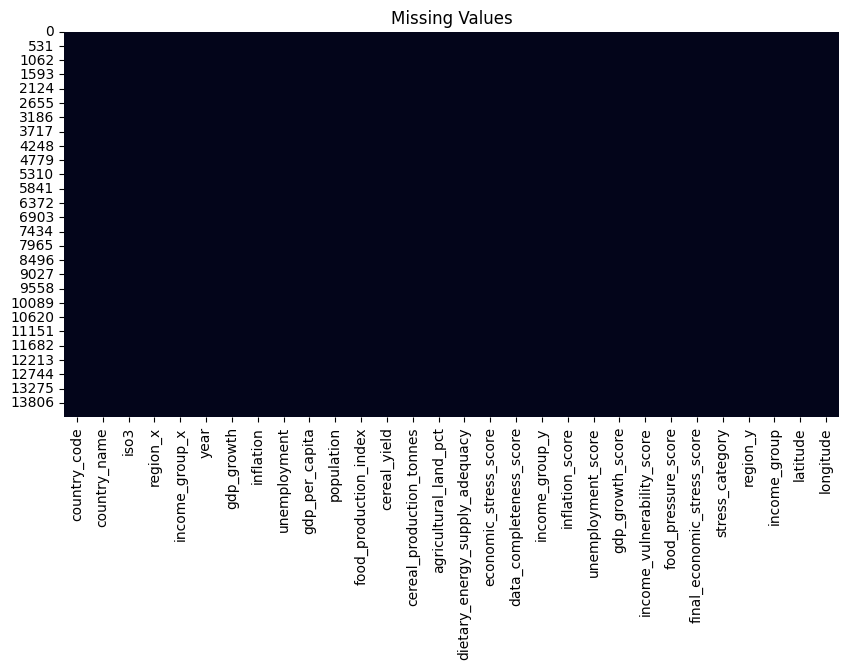

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(
    super_dataset.isnull(),
    cbar=False
)
plt.title("Missing Values")
plt.show()

**9.2 Outlier Detection**

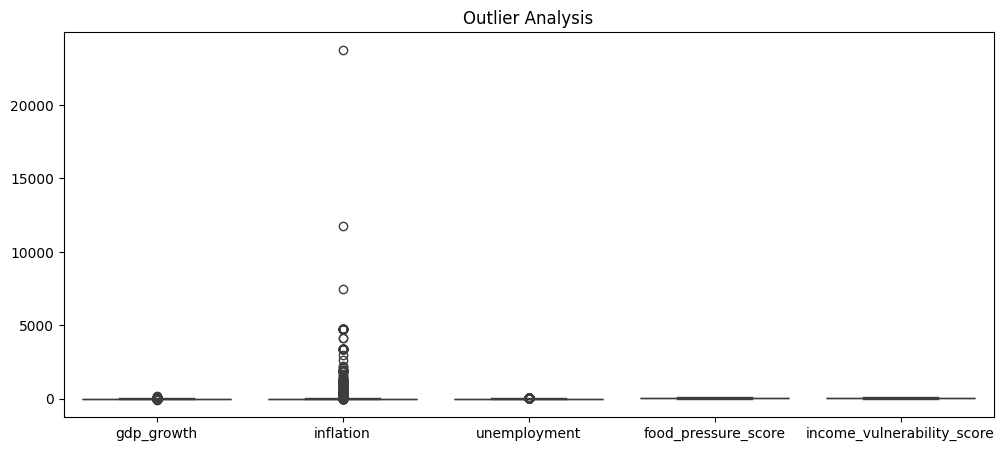

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(
    data=super_dataset[features]
)
plt.title("Outlier Analysis")
plt.show()

**9.3 Economic Stress Trend (India)**

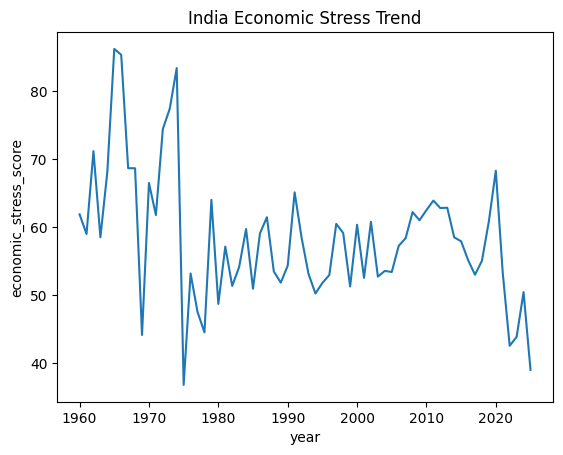

In [ ]:
country = "India"

temp = (
    super_dataset[
        super_dataset["country_name"]
        == country
    ]
)

sns.lineplot(
    data=temp,
    x='year',
    y='economic_stress_score'
)

plt.title(
    f"{country} Economic Stress Trend"
)
plt.show()

**9.4 Regional Comparison**

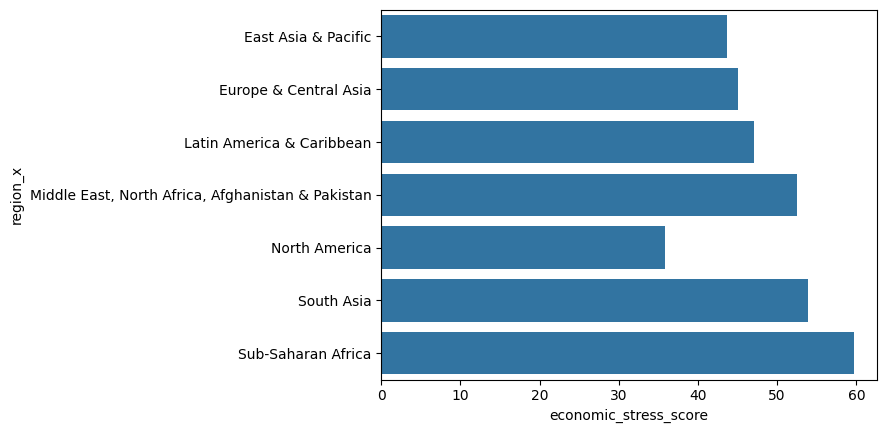

In [ ]:
regional_stress = (
    super_dataset
    .groupby('region_x')
    ['economic_stress_score']
    .mean()
    .reset_index()
)

sns.barplot(
    data=regional_stress,
    x='economic_stress_score',
    y='region_x'
)

plt.show()

**9.5 Corelation Matrix**

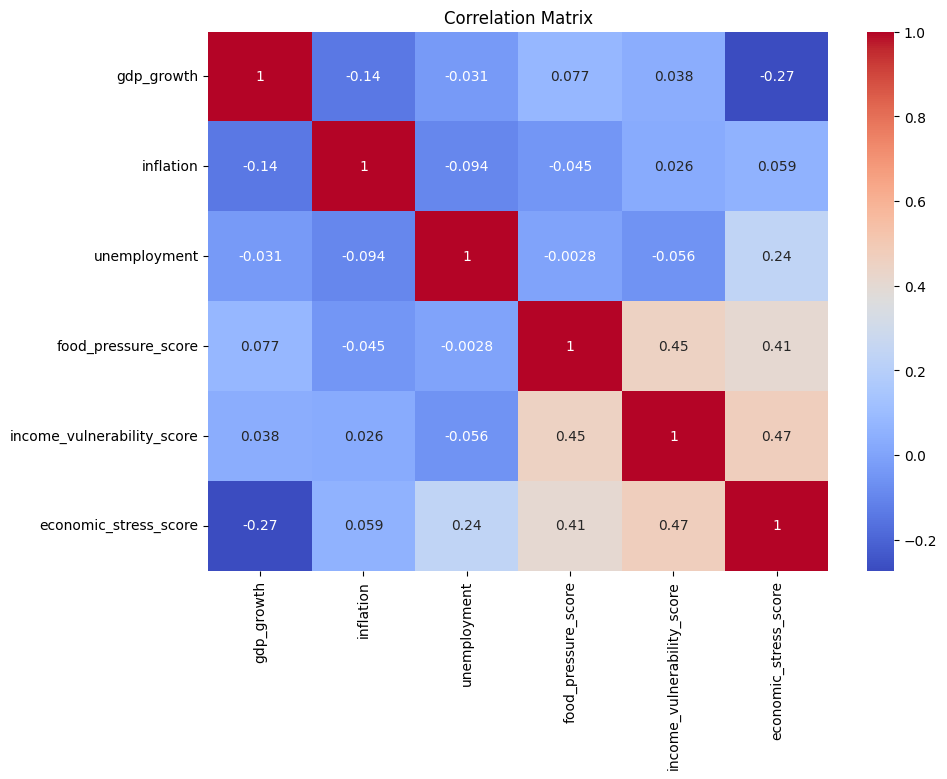

In [ ]:
corr_df = (
    super_dataset[
        features +
        ['economic_stress_score']
    ]
)

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Correlation Matrix"
)

plt.show()

# 10. Country Clustering

**10.1 K-Means**

In [ ]:
print("="*60)
print("COUNTRY SEGMENTATION USING K-MEANS")
print("="*60)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

latest_year = super_dataset['year'].max()

cluster_data = super_dataset[
    super_dataset['year'] == latest_year
].copy()

features = [
    'gdp_growth',
    'inflation',
    'unemployment',
    'food_pressure_score',
    'income_vulnerability_score'
]

X_cluster = cluster_data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

COUNTRY SEGMENTATION USING K-MEANS


**10.2 Elbow Method + Silhouette Analysis**

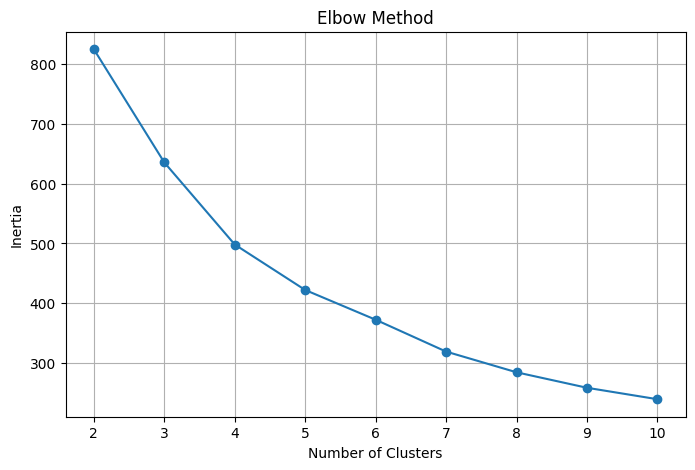

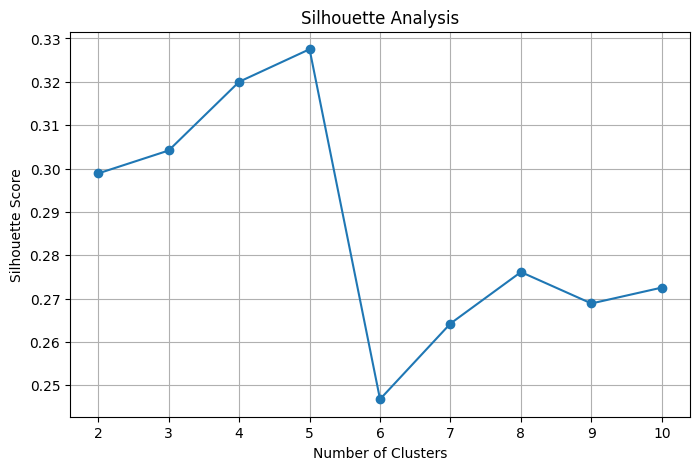

Optimal Clusters: 5


In [ ]:
inertia = []
silhouette_scores = []

for k in range(2, 11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    inertia.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

optimal_k = range(2,11)[
    silhouette_scores.index(max(silhouette_scores))
]

print(f"Optimal Clusters: {optimal_k}")

**10.3 Final KMeans Model**

In [ ]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_data['economic_cluster'] = (
    kmeans.fit_predict(X_scaled)
)

cluster_data.head()

,country_code,country_name,iso3,region_x,income_group_x,year,gdp_growth,inflation,unemployment,gdp_per_capita,...,gdp_growth_score,income_vulnerability_score,food_pressure_score,final_economic_stress_score,stress_category,region_y,income_group,latitude,longitude,economic_cluster
65,ABW,Aruba,ABW,Latin America & Caribbean,High income,2025,6.810777,4.257462,7.972,39498.594129,...,6.735751,16.145833,42.936264,10.77,Unknown,Latin America & Caribbean,High income,12.51670,-70.0167,0
131,AFG,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2025,2.266944,-6.601186,13.351,413.757895,...,60.591133,99.014778,74.488636,89.56,Severe,"Middle East, North Africa, Afghanistan & Pakistan",Low income,34.52280,69.1761,3
197,AGO,Angola,AGO,Sub-Saharan Africa,Lower middle income,2025,4.423907,28.240495,14.108,2665.874448,...,25.388601,75.000000,81.666667,91.21,Severe,Sub-Saharan Africa,Lower middle income,-8.81155,13.2420,3
263,ALB,Albania,ALB,Europe & Central Asia,Upper middle income,2025,4.045928,2.215874,10.926,11377.775743,...,34.196891,44.270833,29.734848,82.97,Severe,Europe & Central Asia,Upper middle income,41.33170,19.8172,0
329,AND,Andorra,AND,Europe & Central Asia,High income,2025,3.371820,12.250420,1.629,49303.649167,...,50.259067,13.020833,98.773006,34.30,Unknown,Europe & Central Asia,High income,42.50750,1.5218,1


**10.4 Cluster Visualization**

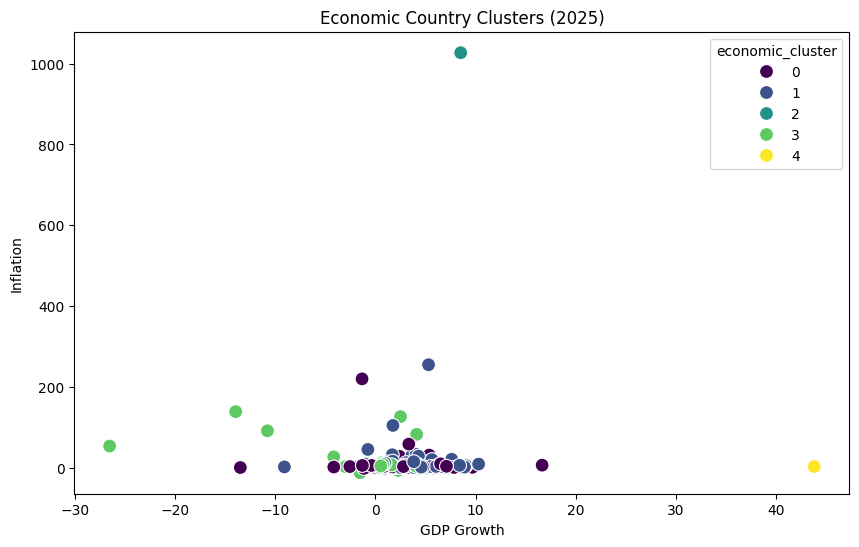

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=cluster_data,
    x='gdp_growth',
    y='inflation',
    hue='economic_cluster',
    palette='viridis',
    s=100
)

plt.title(
    f'Economic Country Clusters ({latest_year})'
)

plt.xlabel('GDP Growth')
plt.ylabel('Inflation')

plt.show()

# 11 Machine Learning Pipeline

In [ ]:
print("="*60)
print("MACHINE LEARNING MODELING")
print("="*60)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.ensemble import RandomForestRegressor

MACHINE LEARNING MODELING


**11.1 Train Test Split**

In [ ]:
X_ml = super_dataset[features]

y_ml = super_dataset[
    'economic_stress_score'
]

X_train, X_test, y_train, y_test = (
    train_test_split(
        X_ml,
        y_ml,
        test_size=0.2,
        random_state=42
    )
)

**11.2 Baseline Random Forest**

In [ ]:
baseline_rf = RandomForestRegressor(
    random_state=42
)

baseline_rf.fit(
    X_train,
    y_train
)

baseline_score = baseline_rf.score(
    X_test,
    y_test
)

print(
    f"Baseline R² Score: {baseline_score:.4f}"
)

Baseline R² Score: 0.8396


**11.4 Feature Importance**

FEATURE IMPORTANCE ANALYSIS


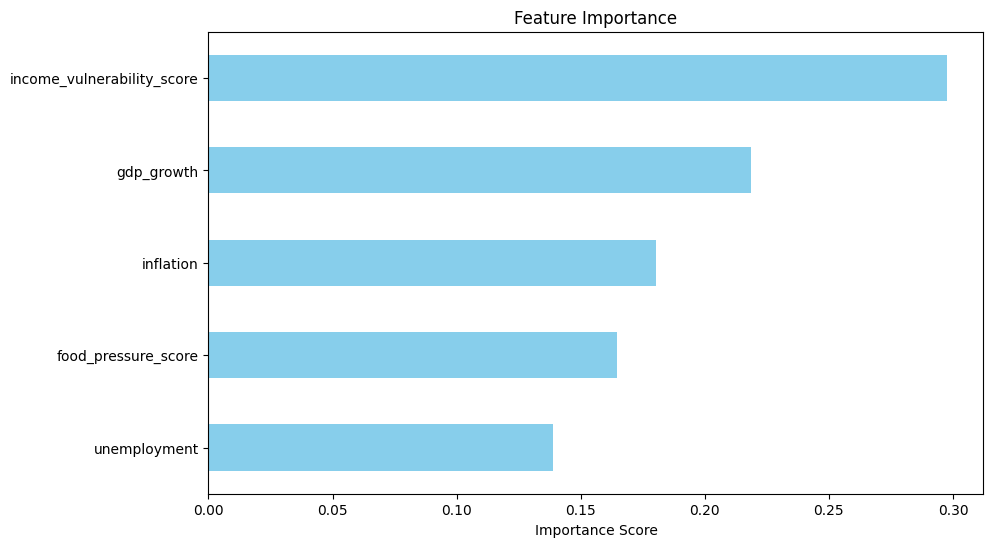

In [ ]:
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_ml, y_ml)

importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(
    ascending=True
)

plt.figure(figsize=(10,6))

importances.plot(
    kind='barh',
    color='skyblue'
)

plt.title(
    'Feature Importance'
)

plt.xlabel('Importance Score')

plt.show()

**11.5 Correlation Matrix**

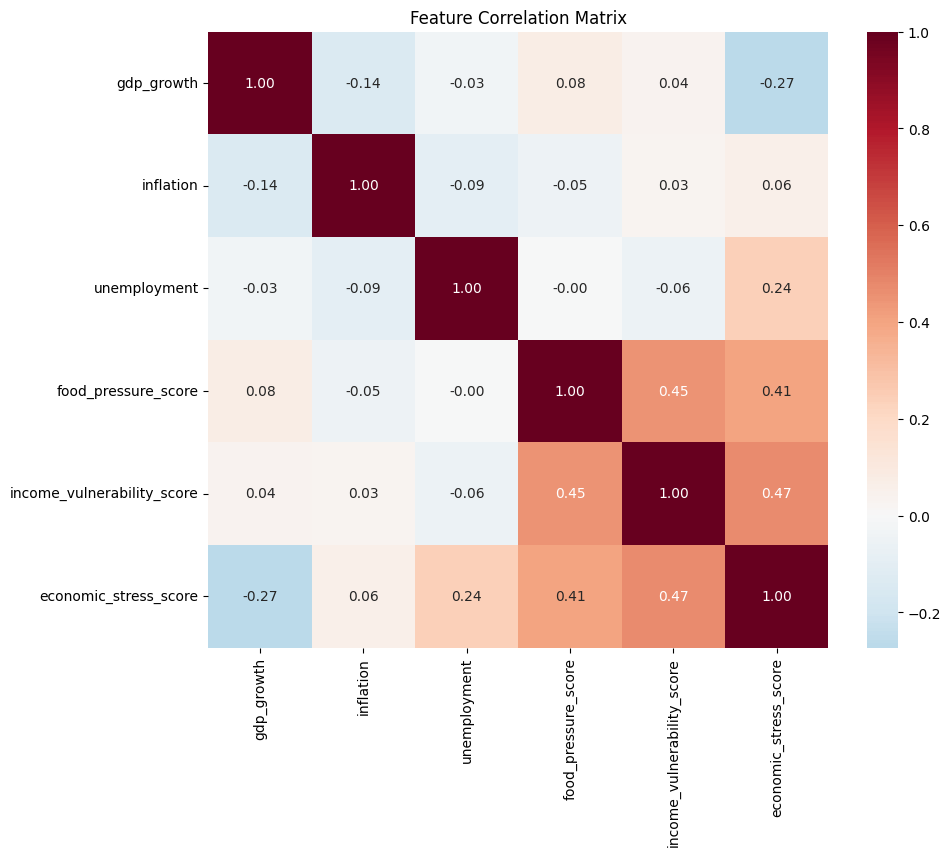

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    super_dataset[
        features +
        ['economic_stress_score']
    ].corr(),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f'
)

plt.title(
    'Feature Correlation Matrix'
)

plt.show()

**11.6 Hyperparameter Tuning**

In [ ]:
param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [None,10,20],
    'min_samples_split': [2,5]
}

rf_base = RandomForestRegressor(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

print("Starting Grid Search...")

grid_search.fit(
    X_train,
    y_train
)

best_rf = grid_search.best_estimator_

print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    f"Optimized R²: {best_rf.score(X_test,y_test):.4f}"
)

improvement = (
    best_rf.score(X_test,y_test)
    - baseline_score
)

print(
    f"Improvement: {improvement:.4f}"
)

Starting Grid Search...
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Optimized R²: 0.8410
Improvement: 0.0014


**12. Model Evaluation**

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error
)

y_pred = best_rf.predict(X_test)

r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")

R² Score : 0.8410
MAE      : 4.8623


**13. Model Persistence**

In [ ]:
print("="*60)
print("MODEL PERSISTENCE")
print("="*60)

import pickle

model_filename = (
    'best_economic_stress_model.pkl'
)

with open(
    model_filename,
    'wb'
) as file:

    pickle.dump(
        best_rf,
        file
    )

print(
    f"Model saved as {model_filename}"
)

MODEL PERSISTENCE
Model saved as best_economic_stress_model.pkl


**13.1 Load Saved Model**

In [ ]:
with open(
    model_filename,
    'rb'
) as file:

    loaded_model = pickle.load(file)

verification_score = (
    loaded_model.score(
        X_test,
        y_test
    )
)

print(
    f"Loaded Model R²: {verification_score:.4f}"
)

Loaded Model R²: 0.8410


**14. Coustom Prediction**

In [ ]:
def predict_custom_stress(
    gdp,
    inflation,
    unemployment,
    food_pressure,
    income_vulnerability
):

    custom_input = pd.DataFrame(
        [[
            gdp,
            inflation,
            unemployment,
            food_pressure,
            income_vulnerability
        ]],
        columns=features
    )

    prediction = (
        loaded_model.predict(
            custom_input
        )[0]
    )

    return prediction

**15. Historical Prediction Analysis**

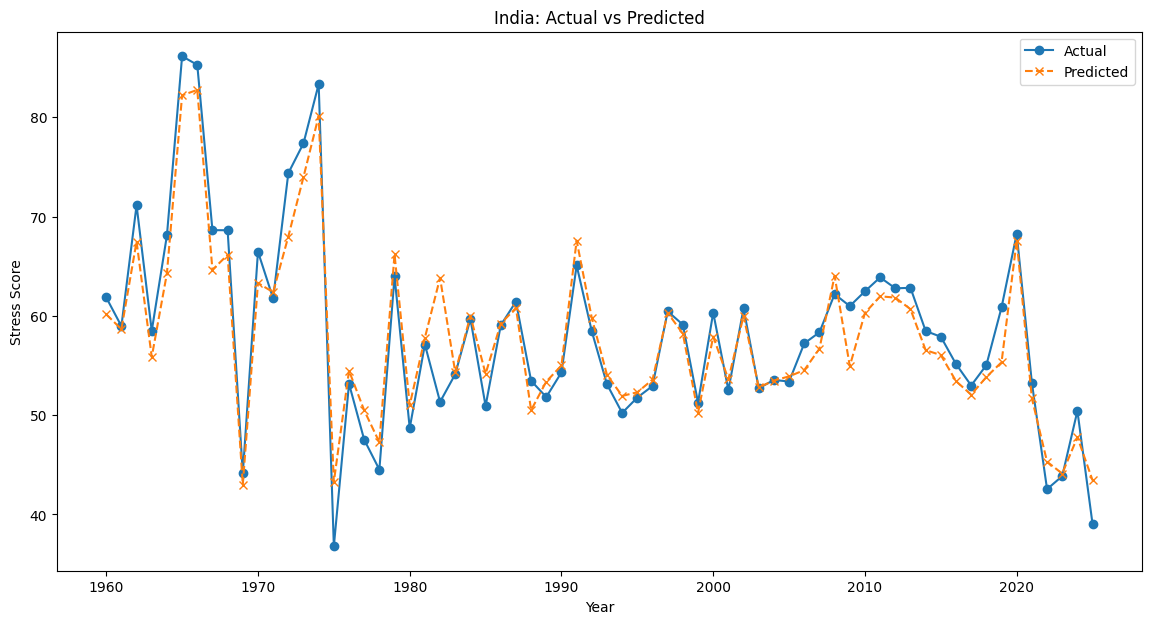

In [ ]:
country = "India"

historical_data = (
    super_dataset[
        super_dataset[
            'country_name'
        ] == country
    ]
    .sort_values('year')
)

historical_data[
    'predicted_stress_score'
] = loaded_model.predict(
    historical_data[features]
)

plt.figure(figsize=(14,7))

plt.plot(
    historical_data['year'],
    historical_data[
        'economic_stress_score'
    ],
    marker='o',
    label='Actual'
)

plt.plot(
    historical_data['year'],
    historical_data[
        'predicted_stress_score'
    ],
    linestyle='--',
    marker='x',
    label='Predicted'
)

plt.title(
    f'{country}: Actual vs Predicted'
)

plt.xlabel("Year")
plt.ylabel("Stress Score")

plt.legend()

plt.show()

**16. Regional Performance Analysis**

In [ ]:
print("="*60)
print("REGIONAL PERFORMANCE ANALYSIS")
print("="*60)

REGIONAL PERFORMANCE ANALYSIS


**16.1 R² By Region**

In [ ]:
region_results = []

unique_regions = (
    super_dataset[
        'region_x'
    ].unique()
)

for region in unique_regions:

    region_indices = (
        super_dataset[
            super_dataset[
                'region_x'
            ] == region
        ].index
    )

    test_indices = (
        y_test.index.intersection(
            region_indices
        )
    )

    if len(test_indices) > 5:

        X_reg = X_test.loc[test_indices]
        y_reg = y_test.loc[test_indices]

        r2 = r2_score(
            y_reg,
            loaded_model.predict(X_reg)
        )

        region_results.append(
            {
                'Region': region,
                'R2_Score': r2
            }
        )

region_perf_df = pd.DataFrame(
    region_results
).sort_values(
    by='R2_Score',
    ascending=False
)

display(region_perf_df)

,Region,R2_Score
4,East Asia & Pacific,0.864168
3,Europe & Central Asia,0.861469
0,Latin America & Caribbean,0.823272
1,"Middle East, North Africa, Afghanistan & Pakistan",0.812724
5,South Asia,0.767748
2,Sub-Saharan Africa,0.737142
6,North America,0.622483


**16.2 MAE By Region**

In [ ]:
region_mae_results = []

for region in unique_regions:

    region_indices = (
        super_dataset[
            super_dataset[
                'region_x'
            ] == region
        ].index
    )

    test_indices = (
        y_test.index.intersection(
            region_indices
        )
    )

    if len(test_indices) > 0:

        X_reg = X_test.loc[test_indices]
        y_reg = y_test.loc[test_indices]

        mae = mean_absolute_error(
            y_reg,
            loaded_model.predict(X_reg)
        )

        region_mae_results.append(
            {
                'Region': region,
                'MAE': mae
            }
        )

region_mae_df = pd.DataFrame(
    region_mae_results
).sort_values(
    by='MAE'
)

display(region_mae_df)

,Region,MAE
3,Europe & Central Asia,4.076011
4,East Asia & Pacific,4.245068
5,South Asia,4.674425
0,Latin America & Caribbean,4.947803
6,North America,5.069026
1,"Middle East, North Africa, Afghanistan & Pakistan",5.726188
2,Sub-Saharan Africa,5.748545


# 17. Statistical Insights

**17.1 GDP Growth vs Economic Stress**

In [ ]:
from scipy.stats import pearsonr

ssa_data = super_dataset[
    super_dataset[
        'region_x'
    ] == 'Sub-Saharan Africa'
]

corr,p = pearsonr(
    ssa_data['gdp_growth'],
    ssa_data['economic_stress_score']
)

print(
    f"Correlation: {corr:.4f}"
)

print(
    f"P-value: {p:.4f}"
)

Correlation: -0.4296
P-value: 0.0000


**17.2 Food Pressure vs Economic Stress**

In [ ]:
corr,p = pearsonr(
    ssa_data[
        'food_pressure_score'
    ],
    ssa_data[
        'economic_stress_score'
    ]
)

print(
    f"Correlation: {corr:.4f}"
)

print(
    f"P-value: {p:.4f}"
)

Correlation: 0.3679
P-value: 0.0000


# 18. Project Summary

In [ ]:
print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print("""
Model Performance
-----------------
R² Score  : ~0.84
MAE       : ~4.86

Key Findings
------------
1. Inflation is a major driver of Economic Stress.

2. Food Pressure significantly impacts
   vulnerable economies.

3. Income Vulnerability contributes
   strongly to economic instability.

4. K-Means successfully segments
   countries into economic groups.

5. Random Forest predicts Economic
   Stress with high accuracy.

Future Improvements
-------------------
• XGBoost
• LightGBM
• SHAP Explainability
• Streamlit Dashboard
• World Bank API Integration
• Time Series Forecasting
""")

PROJECT SUMMARY

Model Performance
-----------------
R² Score  : ~0.84
MAE       : ~4.86

Key Findings
------------
1. Inflation is a major driver of Economic Stress.

2. Food Pressure significantly impacts
   vulnerable economies.

3. Income Vulnerability contributes
   strongly to economic instability.

4. K-Means successfully segments
   countries into economic groups.

5. Random Forest predicts Economic
   Stress with high accuracy.

Future Improvements
-------------------
• XGBoost
• LightGBM
• SHAP Explainability
• Streamlit Dashboard
• World Bank API Integration
• Time Series Forecasting

